# Рубежный контроль №1 (весна 2026)

**Тема:** Технологии разведочного анализа и обработки данных  
**Вариант:** 8  
**Задание:** 1 — корреляционный анализ (`HousingData.csv`)  
**Датасет:** Boston Housing (`HousingData.csv`)

**Студент:** Козлов А.А.  
**Группа:** ИУ5-63Б


## Загрузка данных и краткий обзор

Набор Boston Housing: числовые признаки районов и целевая переменная **`MEDV`** — медианная стоимость жилья (тыс. $). В файле пропуски обозначены как **`NA`**.

In [33]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

BASE = pathlib.Path.cwd()
for candidate in (
    BASE / "HousingData.csv",
    BASE / "РК1" / "HousingData.csv",
):
    if candidate.exists():
        CSV_PATH = candidate
        break
else:
    raise FileNotFoundError(
        "Положите ноутбук в папку РК1 рядом с HousingData.csv или откройте РК1 как рабочую папку."
    )

df_raw = pd.read_csv(CSV_PATH, na_values=["NA", ""])
print("Файл данных: HousingData.csv")
print("Размерность:", df_raw.shape)
print("Имена признаков:", list(df_raw.columns))
df_raw.head()

Файл данных: HousingData.csv
Размерность: (506, 14)
Имена признаков: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [34]:
df_raw.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

## Пропуски и очистка данных

По условию задания строки или столбцы с пропусками удаляются. Здесь удаляются **строки**, в которых есть хотя бы одно отсутствующее значение (`dropna(how="any")`), чтобы сохранить полный набор признаков.

In [35]:
missing_per_col = df_raw.isna().sum().sort_values(ascending=False)
rows_with_any_na = df_raw.isna().any(axis=1).sum()
print("Строк с хотя бы одним пропуском:", int(rows_with_any_na))
print("\nСтолбцы с пропусками:")
print(missing_per_col[missing_per_col > 0])

df = df_raw.dropna(axis=0, how="any").copy()
removed = df_raw.shape[0] - df.shape[0]
print("\nУдалено строк из-за пропусков:", removed)
print("Размерность после очистки:", df.shape)

Строк с хотя бы одним пропуском: 112

Столбцы с пропусками:
CRIM     20
ZN       20
INDUS    20
CHAS     20
LSTAT    20
AGE      20
dtype: int64

Удалено строк из-за пропусков: 112
Размерность после очистки: (394, 14)


## Корреляционный анализ (коэффициент корреляции Пирсона)

Строится матрица парных корреляций между числовыми признаками. Для задачи регрессии целевая переменная — **`MEDV`**; ниже также корреляции остальных признаков с `MEDV` и графики.

In [36]:
corr = df.corr(numeric_only=True, method="pearson")
display(round(corr, 3))

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000,-0.188,0.392,-0.052,0.416,-0.227,0.341,-0.365,0.609,0.561,0.265,-0.386,0.462,-0.397
ZN,-0.188,1.000,-0.521,-0.033,-0.516,0.343,-0.568,0.645,-0.299,-0.306,-0.422,0.170,-0.415,0.407
INDUS,0.392,-0.521,1.000,0.050,0.763,-0.403,0.642,-0.697,0.592,0.734,0.396,-0.345,0.598,-0.511
CHAS,-0.052,-0.033,0.050,1.000,0.077,0.095,0.073,-0.095,0.014,-0.027,-0.105,0.069,-0.037,0.174
NOX,0.416,-0.516,0.763,0.077,1.000,-0.317,0.733,-0.768,0.628,0.680,0.210,-0.384,0.594,-0.459
RM,-0.227,0.343,-0.403,0.095,-0.317,1.000,-0.249,0.219,-0.236,-0.321,-0.391,0.123,-0.636,0.724
AGE,0.341,-0.568,0.642,0.073,0.733,-0.249,1.000,-0.754,0.444,0.504,0.265,-0.282,0.601,-0.407
DIS,-0.365,0.645,-0.697,-0.095,-0.768,0.219,-0.754,1.000,-0.477,-0.530,-0.229,0.285,-0.505,0.280
RAD,0.609,-0.299,0.592,0.014,0.628,-0.236,0.444,-0.477,1.000,0.900,0.442,-0.444,0.511,-0.417
TAX,0.561,-0.306,0.734,-0.027,0.680,-0.321,0.504,-0.530,0.900,1.000,0.447,-0.435,0.572,-0.509


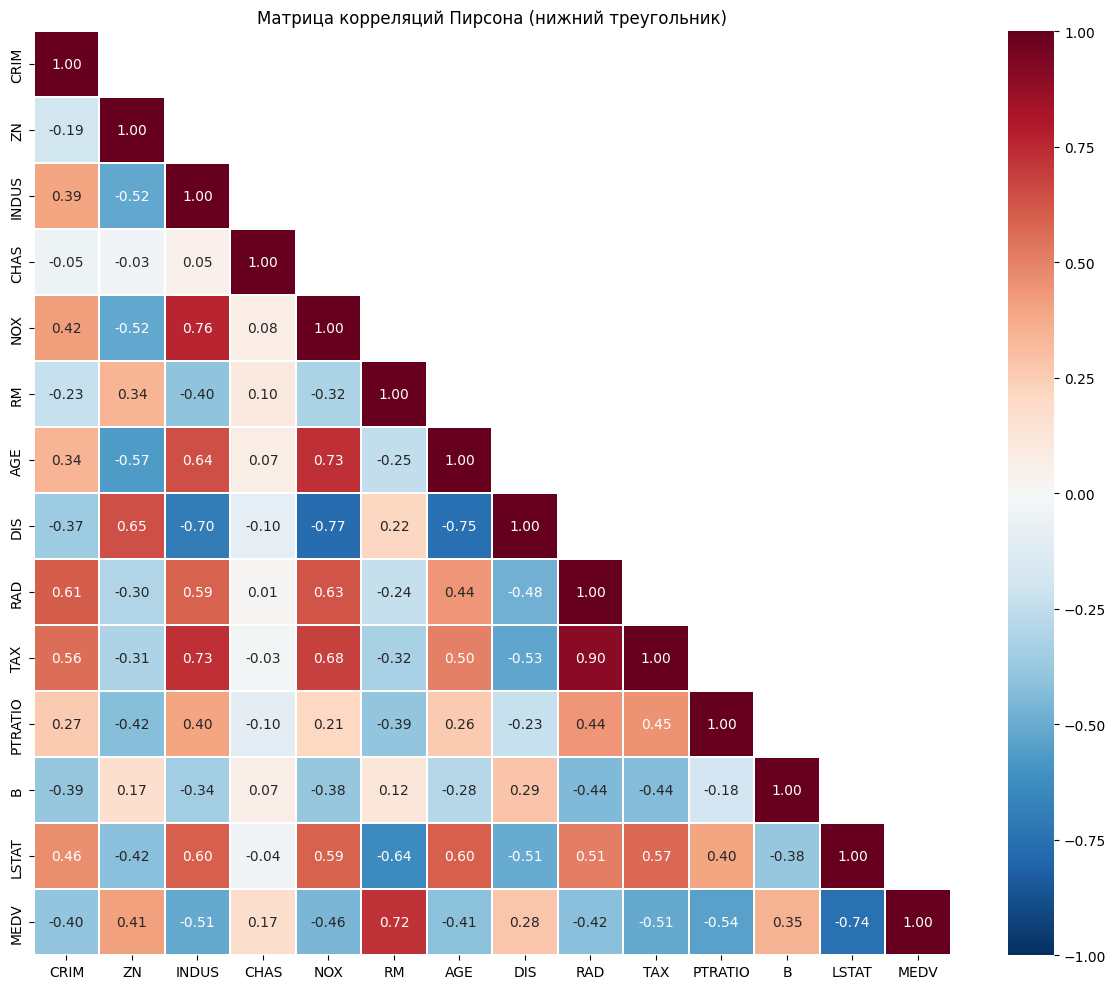

In [37]:
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    ax=ax,
    vmin=-1,
    vmax=1,
)
ax.set_title("Матрица корреляций Пирсона (нижний треугольник)")
plt.tight_layout()
plt.show()

Корреляции признаков с MEDV (по убыванию |r|):


,feature,corr_with_MEDV
0,LSTAT,-0.743450
1,RM,0.723951
2,PTRATIO,-0.543809
3,INDUS,-0.510829
4,TAX,-0.508864
5,NOX,-0.459054
6,RAD,-0.416638
7,AGE,-0.407470
8,ZN,0.406822
9,CRIM,-0.397230


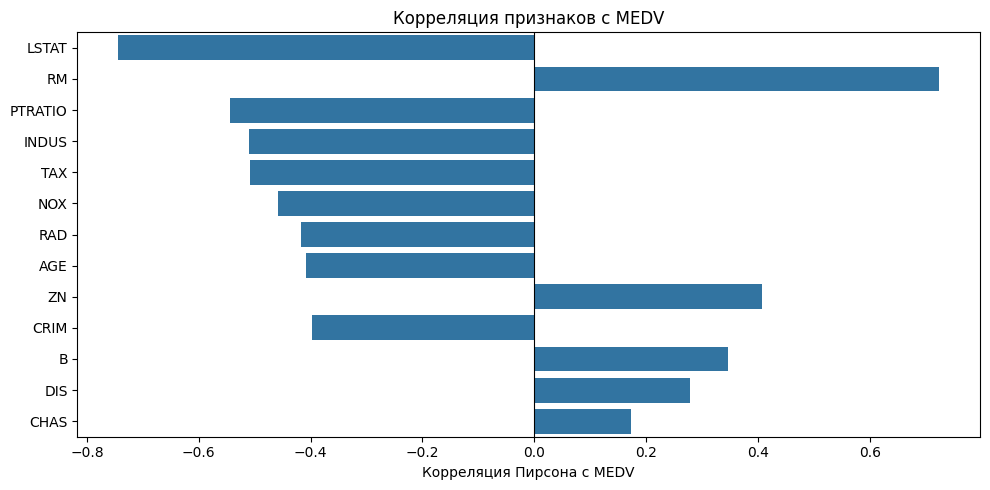

In [38]:
TARGET = "MEDV"
s = corr[TARGET].drop(labels=[TARGET])
corr_target = s.loc[s.abs().sort_values(ascending=False).index]
corr_df = corr_target.rename("corr_with_MEDV").reset_index().rename(columns={"index": "feature"})

print("Корреляции признаков с MEDV (по убыванию |r|):")
display(corr_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=corr_df, x="corr_with_MEDV", y="feature", color="C0")
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Корреляция признаков с {TARGET}")
plt.xlabel("Корреляция Пирсона с MEDV")
plt.ylabel(None)
plt.tight_layout()
plt.show()

### Пары признаков с сильной линейной связью

Пары входных признаков с **|r| > 0,7** (без столбца цели `MEDV`) показывают возможную **мультиколлинеарность** — на неё полезно обращать внимание при линейных моделях.

In [39]:
THRESH = 0.7
feat_cols = list(df.columns)
triu_pairs = []
for i, ai in enumerate(feat_cols):
    for aj in feat_cols[i + 1 :]:
        triu_pairs.append((ai, aj, corr.loc[ai, aj]))
strong = sorted(
    [t for t in triu_pairs if abs(t[2]) > THRESH and TARGET not in (t[0], t[1])],
    key=lambda x: abs(x[2]),
    reverse=True,
)
display(pd.DataFrame(strong, columns=["feature_a", "feature_b", "r_pearson"]))

,feature_a,feature_b,r_pearson
0,RAD,TAX,0.900000
1,NOX,DIS,-0.768137
2,INDUS,NOX,0.762737
3,AGE,DIS,-0.753547
4,INDUS,TAX,0.734204
5,NOX,AGE,0.732540


## Дополнение для группы ИУ5-63Б — ящик с усами (boxplot)

Для произвольной числовой колонки — **`RM`** (среднее число комнат на жилище) — строится диаграмма размаха.

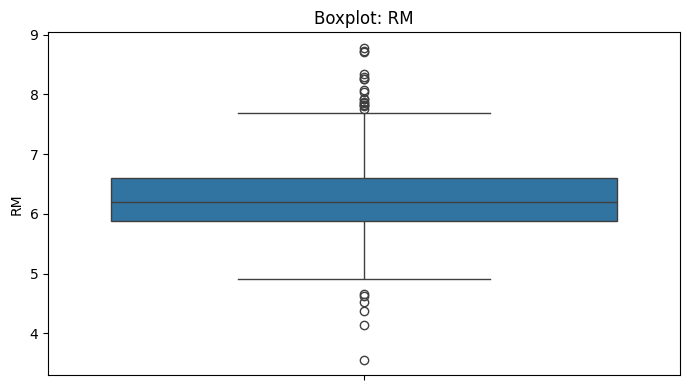

In [40]:
BOXPLOT_COL = "RM"

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, y=BOXPLOT_COL, color="C0")
plt.title(f"Boxplot: {BOXPLOT_COL}")
plt.ylabel(BOXPLOT_COL)
plt.tight_layout()
plt.show()

## Выводы

### Данные и пропуски
Строки с пропусками (`NA`) удалены построчно; корреляции Пирсона считаются по полностью наблюдаемым записям. Объём выборки уменьшается — это плата за простую схему без заполнения пропусков.

### Применимость моделей машинного обучения
- Задача **регрессии**: предсказание `MEDV` по признакам; после очистки данные пригодны для обучения линейных и нелинейных моделей.
- **Линейные модели** чувствительны к мультиколлинеарности; таблица пар с |r| > 0,7 выше подсказывает, какие признаки сильно дублируют друг друга (часто `RAD`–`TAX`, `NOX`–`INDUS` и т.д.).
- **Деревья и ансамбли** устойчивее к нелинейностям, но информативность входов по-прежнему важна.

### Возможный вклад признаков (по корреляции с `MEDV`)
Сильнее всего по модулю линейная связь с ценой обычно у **`LSTAT`** (отрицательная) и **`RM`** (положительная). Признаки **`PTRATIO`, `INDUS`, `TAX`, `NOX`** дают умеренный отрицательный вклад в линейном смысле. Корреляция не отражает взаимодействия признаков; окончательные выводы о важности — по модели и методам интерпретации (важности, SHAP и т.п.).

### Boxplot
По **`RM`** видны медиана, квартили и потенциальные выбросы — полезно при проверке данных перед регрессией.